F1 parsed records: 192
               f1_name        prefix dsm_id   diameter  fil  ht     shape
DSM3-COMBINED-DSM00_Aa DSM3-COMBINED  DSM00 214.336037    0   0 Elongated
DSM3-COMBINED-DSM00_Ab DSM3-COMBINED  DSM00  86.343144    0   0 Elongated
DSM3-COMBINED-DSM00_Ba DSM3-COMBINED  DSM00  35.830153    0   0 Elongated
DSM3-COMBINED-DSM00_Bb DSM3-COMBINED  DSM00 159.664282    0   0 Elongated
 DSM3-COMBINED-DSM01_A DSM3-COMBINED  DSM01 110.633747    0   0     Ovoid

Matched rows: 94
               F1_Name  ODP_Diameter_nm  #Radial_filaments  Holes_and_tunnels Shapes_raw                    F2_ID    LQD_nm    Shapes
DSM3-COMBINED-DSM00_Aa       214.336037                  0                  0  Elongated DSM3-COMBINED-CM50-DSM00 53.516254 Elongated
 DSM3-COMBINED-DSM01_B       112.706995                  0                  0      Ovoid DSM3-COMBINED-CM50-DSM01 48.826158     Ovoid
 DSM3-COMBINED-DSM02_B       122.013774                  0                  0      Ovoid DSM3-COMBINED-CM50-DSM02

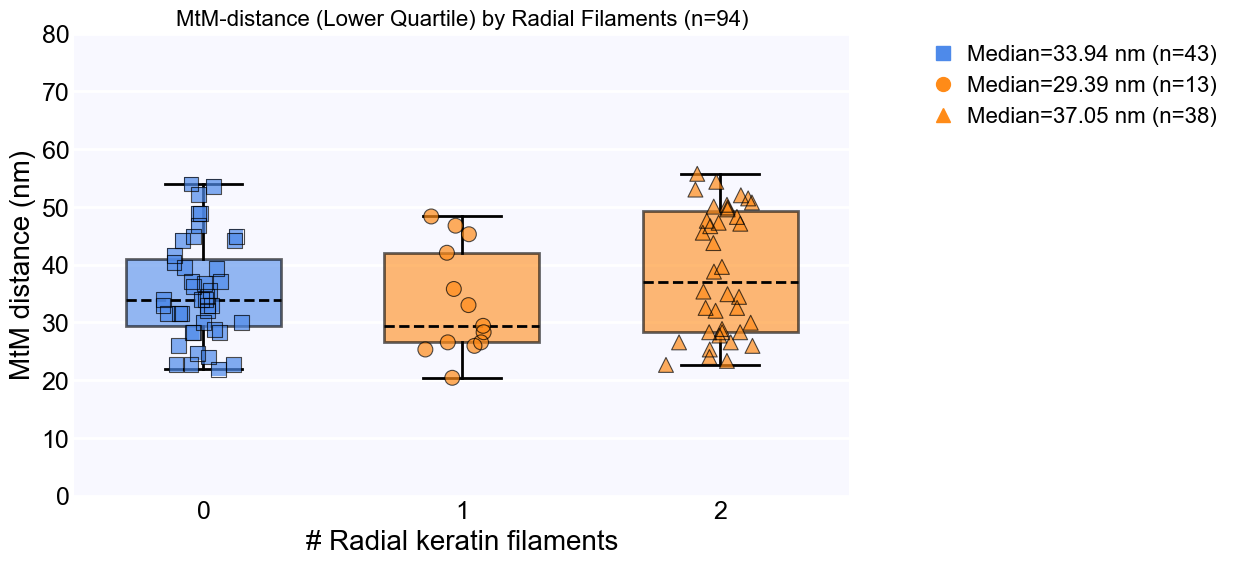

C:\Users\Notapple\AppData\Local\Temp\ipykernel_39736\1414758532.py:273: UserWarning: You passed a edgecolor/edgecolors ('none') for an unfilled marker ('x').  Matplotlib is ignoring the edgecolor in favor of the facecolor.  This behavior may change in the future.
  ax.scatter(x_vals, y_vals, color=color, alpha=0.7,
C:\Users\Notapple\AppData\Local\Temp\ipykernel_39736\1414758532.py:277: UserWarning: You passed a edgecolor/edgecolors ('black') for an unfilled marker ('x').  Matplotlib is ignoring the edgecolor in favor of the facecolor.  This behavior may change in the future.
  ax.scatter(x_vals, y_vals, color="none", alpha=0.7,


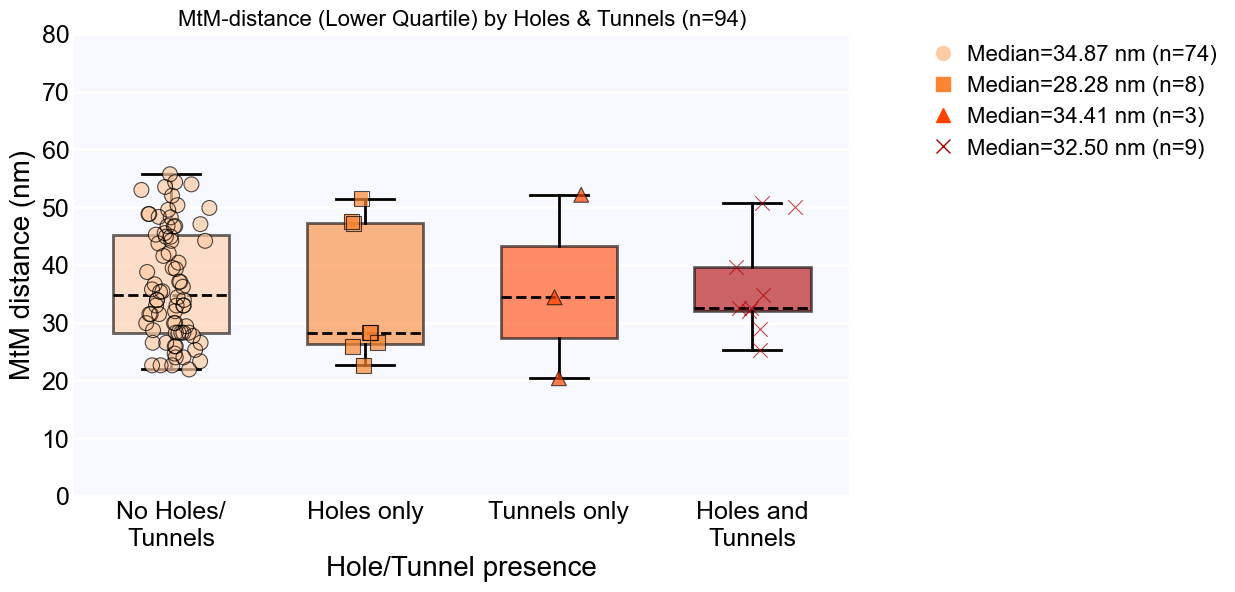

C:\Users\Notapple\AppData\Local\Temp\ipykernel_39736\1414758532.py:273: UserWarning: You passed a edgecolor/edgecolors ('none') for an unfilled marker ('x').  Matplotlib is ignoring the edgecolor in favor of the facecolor.  This behavior may change in the future.
  ax.scatter(x_vals, y_vals, color=color, alpha=0.7,
C:\Users\Notapple\AppData\Local\Temp\ipykernel_39736\1414758532.py:277: UserWarning: You passed a edgecolor/edgecolors ('black') for an unfilled marker ('x').  Matplotlib is ignoring the edgecolor in favor of the facecolor.  This behavior may change in the future.
  ax.scatter(x_vals, y_vals, color="none", alpha=0.7,


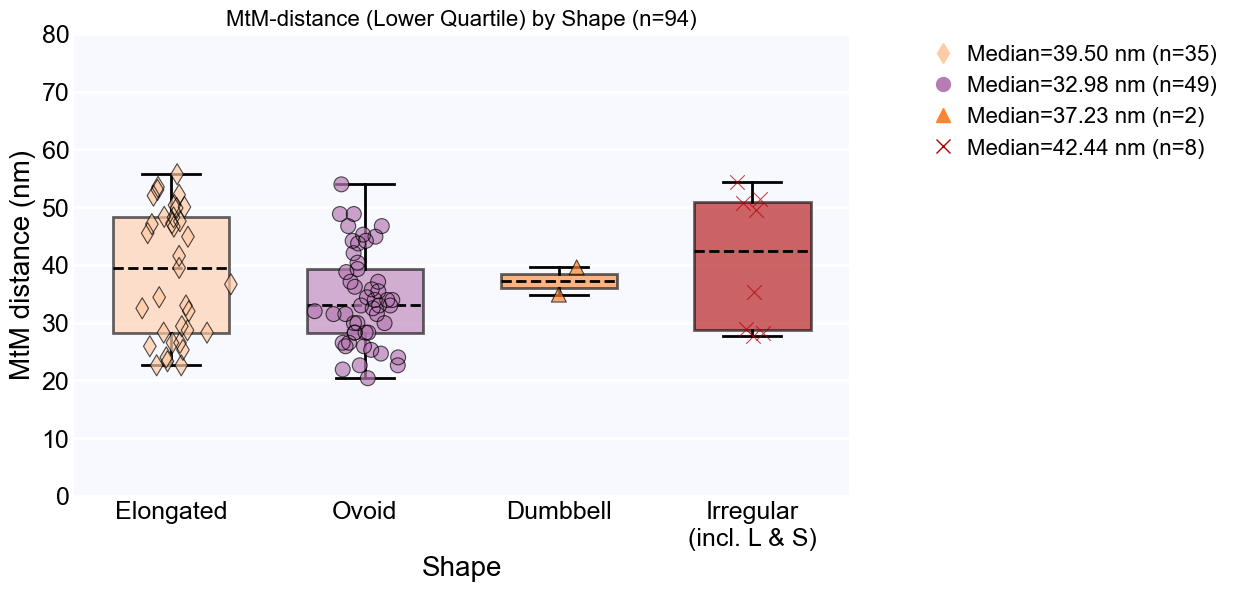

In [1]:
# ---------------------------------------------------------------
# A431 Boxplot: MtM lower quartile distance by filaments / HT / shapes
# F1 = 260503-DSM2-DSM3-intODP-COMBINED.csv, which has all data for individual plaques.
# F2 = 260506-DSM2-DSM3-COMBINED-lower_quartiles.csv, which only has the "ID" and lower quartiles distances
#      obtained by runnning the 20260503-MtM-vtk-plots-A431.ipynb on the vtks. 
# ---------------------------------------------------------------
import matplotlib
import matplotlib.pyplot as plt
import matplotlib.lines as mlines
import numpy as np
import pandas as pd
import os
import re

# ------------------------------
# User Settings
# ------------------------------
input_fileF1 = "260503-DSM2-DSM3-indODP-COMBINED.csv"
input_fileF2 = "260506-DSM2-DSM3-COMBINED-lower_quartiles.csv"
substr = "260503-A431"
output_dir = "./Inter-ODP-Output/"
os.makedirs(output_dir, exist_ok=True)

# ------------------------------
# Font sizes
# ------------------------------
title_fontsize = 16
axis_fontsize  = 20
tick_fontsize  = 18
legend_fontsize = 16

# ------------------------------
# Set fonts to be editable in Illustrator
# ------------------------------
matplotlib.rcParams.update({
    "pdf.fonttype": 42,
    "ps.fonttype": 42,
    "font.family": "Arial",
    "axes.titlesize":   title_fontsize,
    "axes.labelsize":   axis_fontsize,
    "xtick.labelsize":  tick_fontsize,
    "ytick.labelsize":  tick_fontsize,
    "legend.fontsize":  legend_fontsize,
})

# ------------------------------
# Plot appearance
# ------------------------------
np.random.seed(42)
jitter_width   = 0.08
plot_width     = 10
plot_height    = 6
plot_background = "ghostwhite"
y_axis_limits  = (0, 80)       # adjust as needed
point_size     = 110
edge_size      = 115
box_line_width = 2
grid_color     = "white"
grid_linestyle = "-"

# ------------------------------
# Columns
# ------------------------------
f1_name_col     = "Name (NA)_match"
f1_diameter_col = "Corrected length"
f1_fil_col      = "#Radial_filaments"
f1_ht_col       = "Holes_and_tunnels"
f1_shapes_col   = "Shapes"

f2_id_col  = "ID"
f2_lqd_col = "lower quartile distance [nm]"

# ------------------------------
# Prefix maps: F1 prefix -> F2 prefix
# ------------------------------
f1_prefixes = ["DSM2-NKB", "DSM2-SEZ", "DSM3-COMBINED"]
f2_prefixes = ["DSM2-NKB-CM50", "DSM2-SEZ-CM50", "DSM3-COMBINED-CM50"]
f1_to_f2_prefix = dict(zip(f1_prefixes, f2_prefixes))
f2_to_f1_prefix = dict(zip(f2_prefixes, f1_prefixes))

# ------------------------------
# Load data
# ------------------------------
df_f1 = pd.read_csv(input_fileF1)
df_f2 = pd.read_csv(input_fileF2)
df_f2[f2_lqd_col] = pd.to_numeric(df_f2[f2_lqd_col], errors="coerce")

# ------------------------------
# Parsing helpers
# ------------------------------
# F1: PREFIX-DSMXX_AA  e.g. DSM2-NKB-DSM7_A or DSM2-NKB-DSM7_Ab
f1_prefix_pat = "|".join(re.escape(p) for p in f1_prefixes)
f1_pattern = re.compile(
    rf'^({f1_prefix_pat})-(DSM\d+)_([A-Z][a-z]?)$',
    re.IGNORECASE
)

# F2: PREFIX-DSMXX  e.g. DSM2-NKB-CM50-DSM7
f2_prefix_pat = "|".join(re.escape(p) for p in f2_prefixes)
f2_pattern = re.compile(
    rf'^({f2_prefix_pat})-(DSM\d+)$',
    re.IGNORECASE
)

def parse_f1_label(label):
    m = f1_pattern.match(str(label).strip())
    if not m:
        return None
    prefix, dsm_id, subtype = m.group(1), m.group(2), m.group(3)
    return {
        "prefix": prefix.upper(),
        "dsm_id": dsm_id.upper(),
    }

def parse_f2_label(label):
    m = f2_pattern.match(str(label).strip())
    if not m:
        return None
    prefix, dsm_id = m.group(1), m.group(2)
    # Normalise F2 prefix to F1 equivalent
    f1_equiv = next(
        (v for k, v in f2_to_f1_prefix.items() if k.upper() == prefix.upper()),
        prefix
    )
    return {
        "prefix": f1_equiv.upper(),
        "dsm_id": dsm_id.upper(),
    }

# ------------------------------
# Parse F1 — keep max diameter per (prefix, dsm_id) ignoring _A/_B
# ------------------------------
f1_records = []
for _, row in df_f1.iterrows():
    m = f1_pattern.match(str(row[f1_name_col]).strip())
    if not m:
        continue
    prefix, dsm_id = m.group(1).upper(), m.group(2).upper()
    f1_records.append({
        "f1_name":  row[f1_name_col],
        "prefix":   prefix,
        "dsm_id":   dsm_id,
        "diameter": row[f1_diameter_col],
        "fil":      row[f1_fil_col],
        "ht":       row[f1_ht_col],
        "shape":    row[f1_shapes_col],
    })

df_f1_parsed = pd.DataFrame(f1_records)
print(f"F1 parsed records: {len(df_f1_parsed)}")
print(df_f1_parsed.head(5).to_string(index=False))

# Keep only the row with the largest Corrected length per (prefix, dsm_id)
idx_f1 = df_f1_parsed.groupby(["prefix", "dsm_id"])["diameter"].idxmax()
df_f1_max = df_f1_parsed.loc[idx_f1].reset_index(drop=True)

f1_lookup = {
    (r["prefix"], r["dsm_id"]): r
    for _, r in df_f1_max.iterrows()
}

# ------------------------------
# Parse F2 and match to F1
# ------------------------------
matched_rows = []
for _, row in df_f2.iterrows():
    parsed = parse_f2_label(row[f2_id_col])
    if parsed is None:
        continue
    key = (parsed["prefix"], parsed["dsm_id"])
    if key not in f1_lookup:
        continue
    f1_row = f1_lookup[key]
    lqd    = row[f2_lqd_col]
    matched_rows.append({
        "F1_Name":           f1_row["f1_name"],
        "ODP_Diameter_nm":   f1_row["diameter"],
        "#Radial_filaments": f1_row["fil"],
        "Holes_and_tunnels": f1_row["ht"],
        "Shapes_raw":        f1_row["shape"],
        "F2_ID":             row[f2_id_col],
        "LQD_nm":            lqd,
    })

matched_df = pd.DataFrame(matched_rows)

# ------------------------------
# Remap Shapes: L and S -> Irregular
# ------------------------------
def remap_shape(s):
    if str(s) in ["L", "S"]:
        return "Irregular"
    return s

matched_df["Shapes"] = matched_df["Shapes_raw"].apply(remap_shape)

# ------------------------------
# Print preview
# ------------------------------
print(f"\nMatched rows: {len(matched_df)}")
print(matched_df.head(10).to_string(index=False))

# ------------------------------
# Save to Excel
# ------------------------------
excel_out = os.path.join(output_dir, f"{substr}_LQD_matched.xlsx")
matched_df.drop(columns=["Shapes_raw"]).to_excel(excel_out, index=False)
print(f"\nMatched data saved to: {excel_out}")

# ------------------------------
# HT display label map
# ------------------------------
ht_label_map = {
    0: "No Holes/\nTunnels",
    1: "Holes only",
    2: "Tunnels only",
    3: "Holes and\nTunnels",
}

# ================================================================
# Generic boxplot function
# ================================================================
def make_boxplot(data, group_col, group_order, group_colors, group_markers,
                 group_labels, y_col, xlabel, title, filename,
                 y_limits=None):

    fig, ax = plt.subplots(figsize=(plot_width, plot_height))
    ax.set_facecolor(plot_background)
    ax.set_axisbelow(True)
    ax.tick_params(axis="both", which="major", length=0, labelsize=tick_fontsize)

    # Filter to known groups only
    plot_data = data[data[group_col].isin(group_order)].copy()

    box_data  = [plot_data.loc[plot_data[group_col] == grp, y_col].dropna()
                 for grp in group_order]
    counts    = {grp: (plot_data[group_col] == grp).sum() for grp in group_order}
    x_labels  = [group_labels[grp] for grp in group_order]

    box = ax.boxplot(
        box_data,
        labels=x_labels,
        patch_artist=True,
        widths=0.6,
        showfliers=False,
        medianprops=dict(color="black", linestyle="--", linewidth=box_line_width),
        boxprops=dict(edgecolor="black", linewidth=box_line_width),
        whiskerprops=dict(linewidth=box_line_width),
        capprops=dict(linewidth=box_line_width),
    )

    legend_handles = []
    for patch, grp in zip(box["boxes"], group_order):
        color = group_colors[grp]
        patch.set_facecolor(color)
        patch.set_alpha(0.6)
        median_val = plot_data.loc[plot_data[group_col] == grp, y_col].median()
        legend_handles.append(
            plt.Line2D([0], [0],
                       color=color, lw=0,
                       marker=group_markers[grp],
                       markersize=10,
                       label=f"Median={median_val:.2f} nm (n={counts[grp]})")
        )

    # Jittered scatter points
    for i, grp in enumerate(group_order, start=1):
        y_vals = plot_data.loc[plot_data[group_col] == grp, y_col].dropna()
        x_vals = np.random.normal(i, jitter_width, size=len(y_vals))
        color  = group_colors[grp]
        marker = group_markers[grp]
        # filled points
        ax.scatter(x_vals, y_vals, color=color, alpha=0.7,
                   s=point_size, marker=marker,
                   edgecolor="none", linewidth=0.8, zorder=10)
        # edge ring
        ax.scatter(x_vals, y_vals, color="none", alpha=0.7,
                   s=edge_size, marker=marker,
                   edgecolor="black", linewidth=0.8, zorder=10)

    ax.set_xlabel(xlabel, fontsize=axis_fontsize)
    ax.set_ylabel("MtM distance (nm)", fontsize=axis_fontsize)
    if y_limits:
        ax.set_ylim(y_limits)
    ax.set_title(f"{title} (n={len(plot_data)})", fontsize=title_fontsize)

    ax.legend(handles=legend_handles, loc="upper right",
              bbox_to_anchor=(1.5, 1.02),
              handletextpad=0.1, frameon=False, fontsize=legend_fontsize)

    ax.yaxis.grid(True, linestyle=grid_linestyle, color=grid_color, linewidth=2)
    ax.xaxis.grid(False)
    for spine in ax.spines.values():
        spine.set_visible(False)

    for ext in ["png", "pdf"]:
        fig.savefig(os.path.join(output_dir, f"{filename}.{ext}"),
                    dpi=300, bbox_inches="tight")
    plt.show()


# ================================================================
# Plot A: Radial Filaments
# ================================================================
fil_group_order  = [0, 1, 2]
fil_colors       = {0: "#4E8AEA", 1: "#FF8B18", 2: "#FF8B18"}
fil_markers      = {0: "s",       1: "o",       2: "^"}
fil_labels       = {0: "0",       1: "1",       2: "2"}

make_boxplot(
    data         = matched_df,
    group_col    = "#Radial_filaments",
    group_order  = fil_group_order,
    group_colors = fil_colors,
    group_markers= fil_markers,
    group_labels = fil_labels,
    y_col        = "LQD_nm",
    xlabel       = "# Radial keratin filaments",
    title        = "MtM-distance (Lower Quartile) by Radial Filaments",
    filename     = substr + "_LQD_by_Filaments",
    y_limits     = y_axis_limits,
)

# ================================================================
# Plot B: Holes and Tunnels
# ================================================================
ht_group_order  = [0, 1, 2, 3]
ht_colors       = {
    0: "#FFCBA5",
    1: "#FB8531",
    2: "#FF4300",
    3: "#AD0000",
}
ht_markers      = {0: "o", 1: "s", 2: "^", 3: "x"}
ht_labels       = {
    0: "No Holes/\nTunnels",
    1: "Holes only",
    2: "Tunnels only",
    3: "Holes and\nTunnels",
}

make_boxplot(
    data         = matched_df,
    group_col    = "Holes_and_tunnels",
    group_order  = ht_group_order,
    group_colors = ht_colors,
    group_markers= ht_markers,
    group_labels = ht_labels,
    y_col        = "LQD_nm",
    xlabel       = "Hole/Tunnel presence",
    title        = "MtM-distance (Lower Quartile) by Holes & Tunnels",
    filename     = substr + "_LQD_by_HolesTunnels",
    y_limits     = y_axis_limits,
)

# ================================================================
# Plot C: Shapes
# ================================================================
shapes_group_order = ["Elongated", "Ovoid", "Dumbbell", "Irregular"]
shapes_colors = {
    "Elongated":  "#FFCBA5",
    "Ovoid":      "#B77CB4",
    "Dumbbell":   "#FB8531",
    "Irregular":  "#AD0000",
}
shapes_markers = {
    "Elongated":  "d",
    "Ovoid":      "o",
    "Dumbbell":   "^",
    "Irregular":  "x",
}
shapes_labels = {
    "Elongated":  "Elongated",
    "Ovoid":      "Ovoid",
    "Dumbbell":   "Dumbbell",
    "Irregular":  "Irregular\n(incl. L & S)",
}

make_boxplot(
    data         = matched_df,
    group_col    = "Shapes",
    group_order  = shapes_group_order,
    group_colors = shapes_colors,
    group_markers= shapes_markers,
    group_labels = shapes_labels,
    y_col        = "LQD_nm",
    xlabel       = "Shape",
    title        = "MtM-distance (Lower Quartile) by Shape",
    filename     = substr + "_LQD_by_Shapes",
    y_limits     = y_axis_limits,
)

F1 parsed records: 49
                   f1_name               prefix dsm_id    diameter  ht     shape
A_left-260419-FINAL DSM1_A A_LEFT-260419-FINAL    DSM1  523.075062   1     Ovoid
A_left-260419-FINAL DSM1_B A_LEFT-260419-FINAL    DSM1  550.619542   1     Ovoid
A_left-260419-FINAL DSM2_A A_LEFT-260419-FINAL    DSM2  447.773172   1     Ovoid
A_left-260419-FINAL DSM2_B A_LEFT-260419-FINAL    DSM2  459.977978   1     Ovoid
A_left-260419-FINAL DSM3_A A_LEFT-260419-FINAL    DSM3 1178.390000   1 Irregular

Matched rows: 23
                    F1_Name  ODP_Diameter_nm  Holes_and_tunnels Shapes_raw             F2_ID    LQD_nm    Shapes
 A_left-260419-FINAL DSM1_B       550.619542                  1      Ovoid  A_left-CM50-DSM1 44.368491     Ovoid
 A_left-260419-FINAL DSM2_B       459.977978                  1      Ovoid  A_left-CM50-DSM2 45.786298     Ovoid
 A_left-260419-FINAL DSM3_B      1229.840000                  1  Irregular  A_left-CM50-DSM3 42.769435 Irregular
 A_left-260419-FINAL D

C:\Users\Notapple\AppData\Local\Temp\ipykernel_47136\210156704.py:252: UserWarning: You passed a edgecolor/edgecolors ('none') for an unfilled marker ('x').  Matplotlib is ignoring the edgecolor in favor of the facecolor.  This behavior may change in the future.
  ax.scatter(x_vals, y_vals, color=color, alpha=0.7,
C:\Users\Notapple\AppData\Local\Temp\ipykernel_47136\210156704.py:255: UserWarning: You passed a edgecolor/edgecolors ('black') for an unfilled marker ('x').  Matplotlib is ignoring the edgecolor in favor of the facecolor.  This behavior may change in the future.
  ax.scatter(x_vals, y_vals, color="none", alpha=0.7,


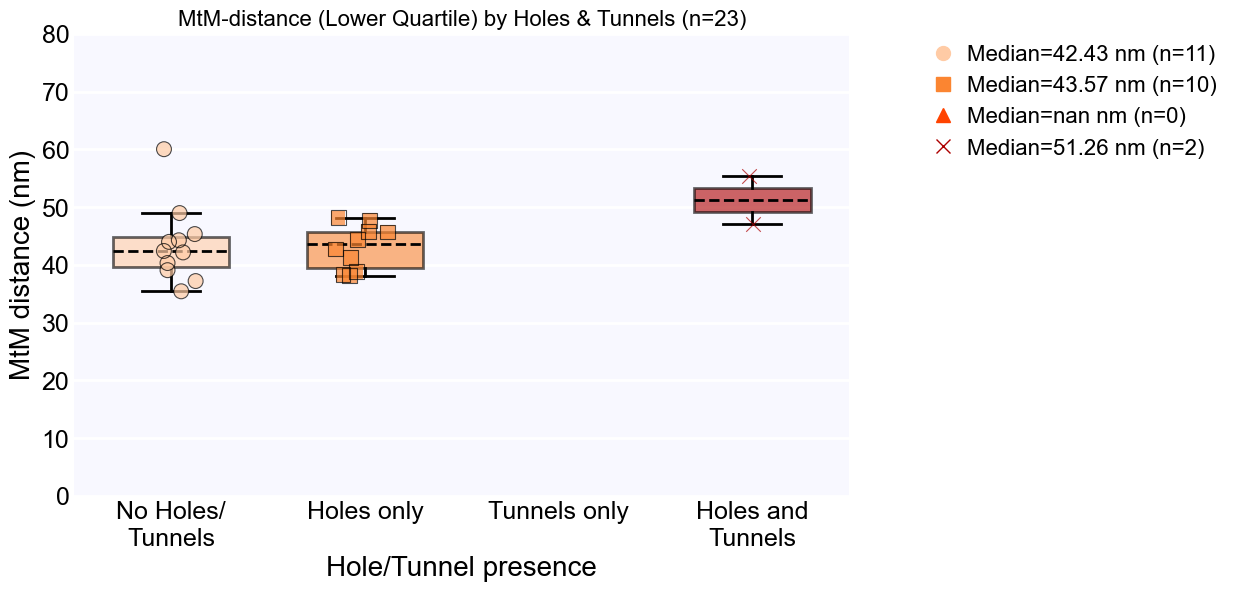

C:\Users\Notapple\AppData\Local\Temp\ipykernel_47136\210156704.py:252: UserWarning: You passed a edgecolor/edgecolors ('none') for an unfilled marker ('x').  Matplotlib is ignoring the edgecolor in favor of the facecolor.  This behavior may change in the future.
  ax.scatter(x_vals, y_vals, color=color, alpha=0.7,
C:\Users\Notapple\AppData\Local\Temp\ipykernel_47136\210156704.py:255: UserWarning: You passed a edgecolor/edgecolors ('black') for an unfilled marker ('x').  Matplotlib is ignoring the edgecolor in favor of the facecolor.  This behavior may change in the future.
  ax.scatter(x_vals, y_vals, color="none", alpha=0.7,


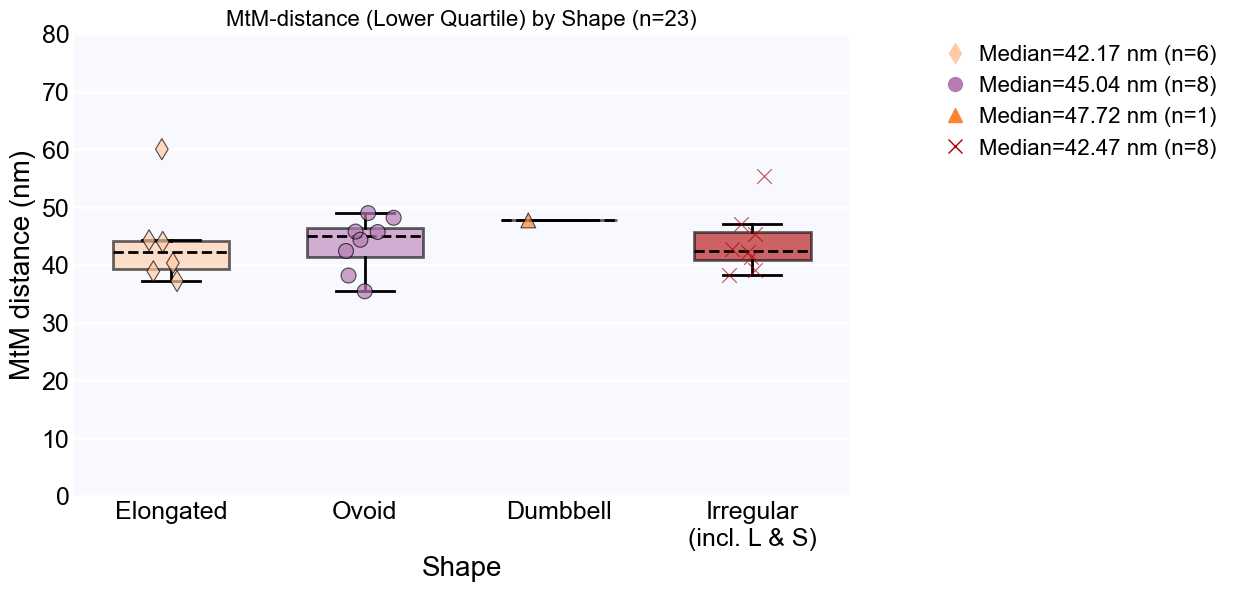

In [10]:
# ---------------------------------------------------------------
# S1 Boxplot: MtM lower quartile distance by HT / Shapes
# F1 = 260503-S1-HMEC-indODP-COMBINED.csv, which has all data for individual plaques.
# F2 = 260506-S1-CM50-COMBINED-vtk_lower_quartiles.csv, which only has the "ID" and lower quartiles distances
#      obtained by runnning the 20260503-MtM-vtk-plots-S1.ipynb on the vtks. 
# ---------------------------------------------------------------
import matplotlib
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import os
import re

# ------------------------------
# User Settings
# ------------------------------
input_fileF1 = "260503-S1-HMEC-indODP-COMBINED.csv"
input_fileF2 = "260506-S1-CM50-COMBINED-vtk_lower_quartiles.csv"
substr = "260503-S1-HMEC"
output_dir = "./Inter-ODP-Output/"
os.makedirs(output_dir, exist_ok=True)

# ------------------------------
# Font sizes
# ------------------------------
title_fontsize  = 16
axis_fontsize   = 20
tick_fontsize   = 18
legend_fontsize = 16

# ------------------------------
# Set fonts to be editable in Illustrator
# ------------------------------
matplotlib.rcParams.update({
    "pdf.fonttype": 42,
    "ps.fonttype": 42,
    "font.family": "Arial",
    "axes.titlesize":  title_fontsize,
    "axes.labelsize":  axis_fontsize,
    "xtick.labelsize": tick_fontsize,
    "ytick.labelsize": tick_fontsize,
    "legend.fontsize": legend_fontsize,
})

# ------------------------------
# Plot appearance
# ------------------------------
np.random.seed(42)
jitter_width    = 0.08
plot_width      = 10
plot_height     = 6
plot_background = "ghostwhite"
y_axis_limits   = (0, 80)      # adjust as needed
point_size      = 110
edge_size       = 115
box_line_width  = 2
grid_color      = "white"
grid_linestyle  = "-"

# ------------------------------
# Columns
# ------------------------------
f1_name_col     = "Name (NA)_match"
f1_diameter_col = "Corrected length"
f1_ht_col       = "Holes_and_tunnels"
f1_shapes_col   = "Shapes"

f2_id_col  = "ID"
f2_lqd_col = "lower quartile distance [nm]"

# ------------------------------
# Prefix maps: F1 prefix -> F2 prefix
# ------------------------------
f1_prefixes = [
    "A_left-260419-FINAL ",
    "A_right-260419-FINAL ",
    "C_260419-FINAL ",
    "MA-260419-FINAL ",
]
f2_prefixes = [
    "A_left-CM50",
    "A_right-CM50",
    "C_CM50",
    "MA-CM50",
]
f2_to_f1_prefix = dict(zip(f2_prefixes, f1_prefixes))

# ------------------------------
# Load data
# ------------------------------
df_f1 = pd.read_csv(input_fileF1)
df_f2 = pd.read_csv(input_fileF2)
df_f2[f2_lqd_col] = pd.to_numeric(df_f2[f2_lqd_col], errors="coerce")

# ------------------------------
# Parsing helpers
# ------------------------------
# F1: PREFIX-DSMXX_AA  e.g. A_left-260419-FINAL-DSM7_A or A_left-260419-FINAL-DSM7_Ab
f1_prefix_pat = "|".join(re.escape(p) for p in f1_prefixes)
f1_pattern = re.compile(
    rf'^({f1_prefix_pat})(DSM\d+)_([A-Z][a-z]?)$',
    re.IGNORECASE
)

# F2: PREFIX-DSMXX  e.g. A_left-CM50-DSM7
f2_prefix_pat = "|".join(re.escape(p) for p in f2_prefixes)
f2_pattern = re.compile(
    rf'^({f2_prefix_pat})-(DSM\d+)$',
    re.IGNORECASE
)

def parse_f2_label(label):
    m = f2_pattern.match(str(label).strip())
    if not m:
        return None
    prefix, dsm_id = m.group(1), m.group(2)
    f1_equiv = next(
        (v for k, v in f2_to_f1_prefix.items() if k.upper() == prefix.upper()),
        prefix
    )
    return {"prefix": f1_equiv.upper(), "dsm_id": dsm_id.upper()}

# ------------------------------
# Parse F1 — keep max diameter per (prefix, dsm_id) ignoring _A/_B
# ------------------------------
f1_records = []
for _, row in df_f1.iterrows():
    m = f1_pattern.match(str(row[f1_name_col]).strip())
    if not m:
        continue
    prefix, dsm_id = m.group(1).upper(), m.group(2).upper()
    f1_records.append({
        "f1_name":  row[f1_name_col],
        "prefix":   prefix,
        "dsm_id":   dsm_id,
        "diameter": row[f1_diameter_col],
        "ht":       row[f1_ht_col],
        "shape":    row[f1_shapes_col],
    })

df_f1_parsed = pd.DataFrame(f1_records)
print(f"F1 parsed records: {len(df_f1_parsed)}")
print(df_f1_parsed.head(5).to_string(index=False))

# Keep only largest Corrected length per (prefix, dsm_id)
idx_f1 = df_f1_parsed.groupby(["prefix", "dsm_id"])["diameter"].idxmax()
df_f1_max = df_f1_parsed.loc[idx_f1].reset_index(drop=True)

f1_lookup = {
    (r["prefix"], r["dsm_id"]): r
    for _, r in df_f1_max.iterrows()
}

# ------------------------------
# Parse F2 and match to F1
# ------------------------------
matched_rows = []
for _, row in df_f2.iterrows():
    parsed = parse_f2_label(row[f2_id_col])
    if parsed is None:
        continue
    key = (parsed["prefix"], parsed["dsm_id"])
    if key not in f1_lookup:
        continue
    f1_row = f1_lookup[key]
    matched_rows.append({
        "F1_Name":           f1_row["f1_name"],
        "ODP_Diameter_nm":   f1_row["diameter"],
        "Holes_and_tunnels": f1_row["ht"],
        "Shapes_raw":        f1_row["shape"],
        "F2_ID":             row[f2_id_col],
        "LQD_nm":            row[f2_lqd_col],
    })

matched_df = pd.DataFrame(matched_rows)

# ------------------------------
# Remap Shapes: L and S -> Irregular
# ------------------------------
def remap_shape(s):
    return "Irregular" if str(s) in ["L", "S"] else s

matched_df["Shapes"] = matched_df["Shapes_raw"].apply(remap_shape)

# ------------------------------
# Print preview
# ------------------------------
print(f"\nMatched rows: {len(matched_df)}")
print(matched_df.head(10).to_string(index=False))

# ------------------------------
# Save to Excel
# ------------------------------
excel_out = os.path.join(output_dir, f"{substr}_LQD_matched.xlsx")
matched_df.drop(columns=["Shapes_raw"]).to_excel(excel_out, index=False)
print(f"\nMatched data saved to: {excel_out}")

# ================================================================
# Generic boxplot function
# ================================================================
def make_boxplot(data, group_col, group_order, group_colors, group_markers,
                 group_labels, y_col, xlabel, title, filename,
                 y_limits=None):

    plot_data = data[data[group_col].isin(group_order)].copy()

    if plot_data.empty:
        print(f"  Skipping '{filename}' — no data after filtering.")
        return

    fig, ax = plt.subplots(figsize=(plot_width, plot_height))
    ax.set_facecolor(plot_background)
    ax.set_axisbelow(True)
    ax.tick_params(axis="both", which="major", length=0, labelsize=tick_fontsize)

    box_data = [plot_data.loc[plot_data[group_col] == grp, y_col].dropna()
                for grp in group_order]
    counts   = {grp: (plot_data[group_col] == grp).sum() for grp in group_order}
    x_labels = [group_labels[grp] for grp in group_order]

    box = ax.boxplot(
        box_data,
        labels=x_labels,
        patch_artist=True,
        widths=0.6,
        showfliers=False,
        medianprops=dict(color="black", linestyle="--", linewidth=box_line_width),
        boxprops=dict(edgecolor="black", linewidth=box_line_width),
        whiskerprops=dict(linewidth=box_line_width),
        capprops=dict(linewidth=box_line_width),
    )

    legend_handles = []
    for patch, grp in zip(box["boxes"], group_order):
        color = group_colors[grp]
        patch.set_facecolor(color)
        patch.set_alpha(0.6)
        median_val = plot_data.loc[plot_data[group_col] == grp, y_col].median()
        legend_handles.append(
            plt.Line2D([0], [0],
                       color=color, lw=0,
                       marker=group_markers[grp],
                       markersize=10,
                       label=f"Median={median_val:.2f} nm (n={counts[grp]})")
        )

    # Jittered scatter overlay
    for i, grp in enumerate(group_order, start=1):
        y_vals = plot_data.loc[plot_data[group_col] == grp, y_col].dropna()
        x_vals = np.random.normal(i, jitter_width, size=len(y_vals))
        color  = group_colors[grp]
        marker = group_markers[grp]
        ax.scatter(x_vals, y_vals, color=color, alpha=0.7,
                   s=point_size, marker=marker,
                   edgecolor="none", linewidth=0.8, zorder=10)
        ax.scatter(x_vals, y_vals, color="none", alpha=0.7,
                   s=edge_size, marker=marker,
                   edgecolor="black", linewidth=0.8, zorder=10)

    ax.set_xlabel(xlabel, fontsize=axis_fontsize)
    ax.set_ylabel("MtM distance (nm)", fontsize=axis_fontsize)
    if y_limits:
        ax.set_ylim(y_limits)
    ax.set_title(f"{title} (n={len(plot_data)})", fontsize=title_fontsize)

    ax.legend(handles=legend_handles, loc="upper right",
              bbox_to_anchor=(1.5, 1.02),
              handletextpad=0.1, frameon=False, fontsize=legend_fontsize)

    ax.yaxis.grid(True, linestyle=grid_linestyle, color=grid_color, linewidth=2)
    ax.xaxis.grid(False)
    for spine in ax.spines.values():
        spine.set_visible(False)

    for ext in ["png", "pdf"]:
        fig.savefig(os.path.join(output_dir, f"{filename}.{ext}"),
                    dpi=300, bbox_inches="tight")
    plt.show()


# ================================================================
# Plot configs
# ================================================================

# --- Holes & Tunnels ---
ht_group_order = [0, 1, 2, 3]
ht_colors      = {0: "#FFCBA5", 1: "#FB8531", 2: "#FF4300", 3: "#AD0000"}
ht_markers     = {0: "o",       1: "s",       2: "^",       3: "x"}
ht_labels      = {
    0: "No Holes/\nTunnels",
    1: "Holes only",
    2: "Tunnels only",
    3: "Holes and\nTunnels",
}

# --- Shapes ---
shapes_group_order = ["Elongated", "Ovoid", "Dumbbell", "Irregular"]
shapes_colors  = {
    "Elongated":  "#FFCBA5",
    "Ovoid":      "#B77CB4",
    "Dumbbell":   "#FB8531",
    "Irregular":  "#AD0000",
}
shapes_markers = {
    "Elongated":  "d",
    "Ovoid":      "o",
    "Dumbbell":   "^",
    "Irregular":  "x",
}
shapes_labels  = {
    "Elongated":  "Elongated",
    "Ovoid":      "Ovoid",
    "Dumbbell":   "Dumbbell",
    "Irregular":  "Irregular\n(incl. L & S)",
}

# ================================================================
# Plot B: Holes & Tunnels
# ================================================================
make_boxplot(
    data          = matched_df,
    group_col     = "Holes_and_tunnels",
    group_order   = ht_group_order,
    group_colors  = ht_colors,
    group_markers = ht_markers,
    group_labels  = ht_labels,
    y_col         = "LQD_nm",
    xlabel        = "Hole/Tunnel presence",
    title         = "MtM-distance (Lower Quartile) by Holes & Tunnels",
    filename      = substr + "_LQD_by_HolesTunnels",
    y_limits      = y_axis_limits,
)

# ================================================================
# Plot C: Shapes
# ================================================================
make_boxplot(
    data          = matched_df,
    group_col     = "Shapes",
    group_order   = shapes_group_order,
    group_colors  = shapes_colors,
    group_markers = shapes_markers,
    group_labels  = shapes_labels,
    y_col         = "LQD_nm",
    xlabel        = "Shape",
    title         = "MtM-distance (Lower Quartile) by Shape",
    filename      = substr + "_LQD_by_Shapes",
    y_limits      = y_axis_limits,
)